In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
matches = pd.read_csv('C:/Users/Lenovo/Downloads/matches.csv')
deliveries = pd.read_csv('C:/Users/Lenovo/Downloads/deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
matches.head()

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print("Seasons covered:", sorted(matches['season'].unique()))
print("Total matches:", len(matches))
print("Total teams:", matches['team1'].nunique())
print("\nMissing values:\n", matches.isnull().sum())

Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total matches: 1095
Total teams: 19

Missing values:
 id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


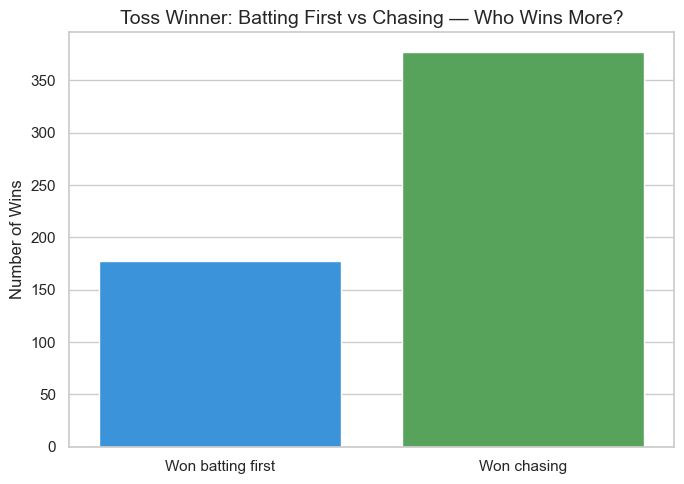

In [5]:
toss_match = matches[matches['toss_decision'] == 'bat'].copy()
bat_first_wins = matches[
    (matches['toss_decision'] == 'bat') & 
    (matches['toss_winner'] == matches['winner'])
].shape[0]

chase_wins = matches[
    (matches['toss_decision'] == 'field') & 
    (matches['toss_winner'] == matches['winner'])
].shape[0]

labels = ['Won batting first', 'Won chasing']
values = [bat_first_wins, chase_wins]

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=values, palette=['#2196F3', '#4CAF50'])
plt.title('Toss Winner: Batting First vs Chasing — Who Wins More?', fontsize=14)
plt.ylabel('Number of Wins')
plt.tight_layout()
plt.savefig('toss_analysis.png', dpi=150)
plt.show()

In [10]:
print(deliveries.columns.tolist())

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


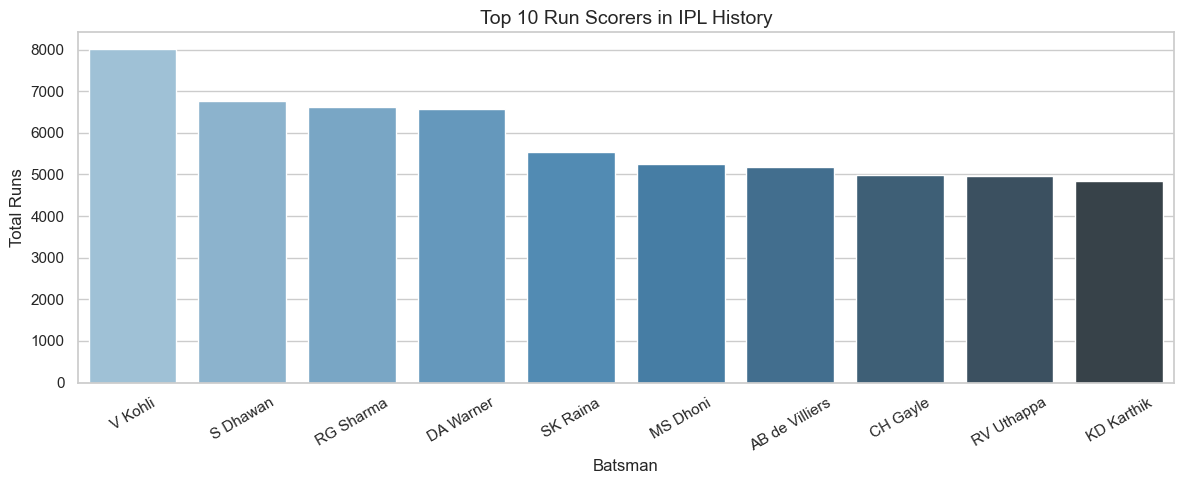

In [12]:
top_batsmen = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_batsmen.columns = ['Batsman', 'Total Runs']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_batsmen, x='Batsman', y='Total Runs', palette='Blues_d')
plt.title('Top 10 Run Scorers in IPL History', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150)
plt.show()

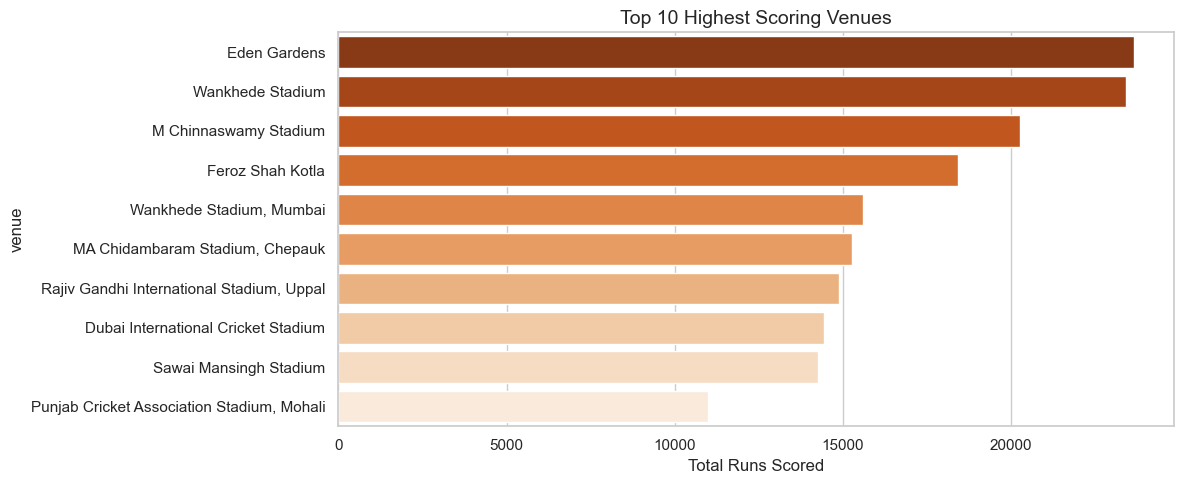

In [7]:
venue_runs = (
    deliveries.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
    .groupby('venue')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=venue_runs, x='total_runs', y='venue', palette='Oranges_r')
plt.title('Top 10 Highest Scoring Venues', fontsize=14)
plt.xlabel('Total Runs Scored')
plt.tight_layout()
plt.savefig('venues.png', dpi=150)
plt.show()

In [13]:
venue_runs = (
    deliveries.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
    .groupby('venue')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [14]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


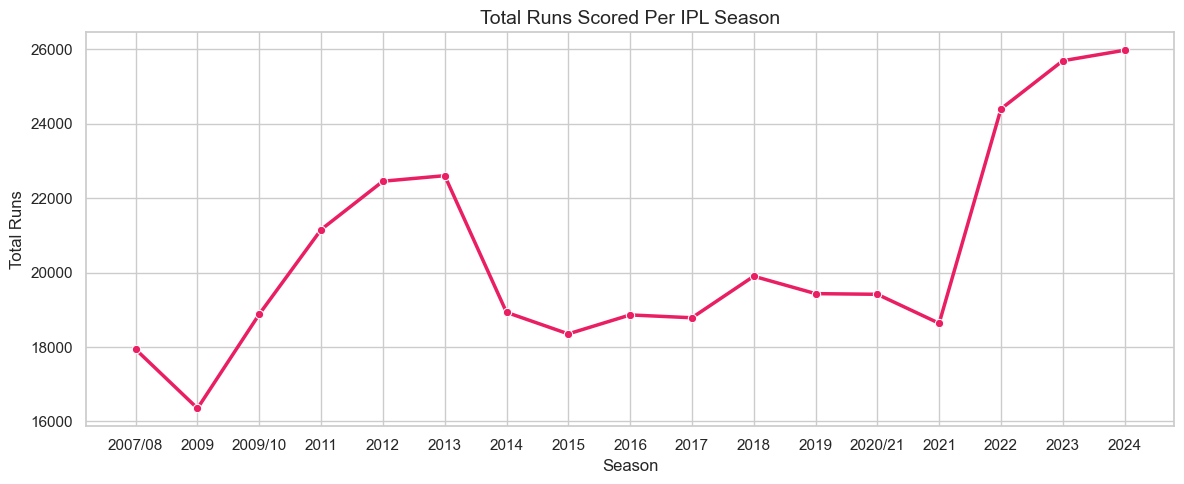

In [15]:
season_runs = (
    deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=season_runs, x='season', y='total_runs', marker='o', color='#E91E63', linewidth=2.5)
plt.title('Total Runs Scored Per IPL Season', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig('season_trends.png', dpi=150)
plt.show()

In [16]:
print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"✅ Total IPL matches analysed: {len(matches)}")
print(f"✅ Seasons covered: {matches['season'].min()} - {matches['season'].max()}")
print(f"✅ Top run scorer: {top_batsmen.iloc[0]['Batsman']} ({top_batsmen.iloc[0]['Total Runs']} runs)")
print(f"✅ Highest scoring venue: {venue_runs.iloc[0]['venue']}")
print(f"✅ Teams that won batting first (toss): {bat_first_wins}")
print(f"✅ Teams that won chasing (toss): {chase_wins}")

KEY INSIGHTS
✅ Total IPL matches analysed: 1095
✅ Seasons covered: 2007/08 - 2024
✅ Top run scorer: V Kohli (8014 runs)
✅ Highest scoring venue: Eden Gardens
✅ Teams that won batting first (toss): 177
✅ Teams that won chasing (toss): 377
